In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import bin2cell as b2c
import numpy as np

In [2]:
# original adatas (h5ad from cell segmentation process)
ab01=sc.read('/Users/rikac/Documents/mansfield_lab/spring_26/cell_segmentation/AB01/AB01_b2c.h5ad')
ab02=sc.read('/Users/rikac/Documents/mansfield_lab/spring_26/cell_segmentation/AB02/AB02_b2c.h5ad')

# segmentation file
ab01_seg = '/Users/rikac/Documents/mansfield_lab/spring_26/cell_segmentation/AB01/AB01_he.npz'
ab02_seg = '/Users/rikac/Documents/mansfield_lab/spring_26/cell_segmentation/AB02/AB02_he.npz'

# tiff images
ab01_img = '/Users/rikac/Documents/mansfield_lab/spring_26/cell_segmentation/AB01/AB01_he_scaled.tiff'
ab02_img = '/Users/rikac/Documents/mansfield_lab/spring_26/cell_segmentation/AB02/AB02_he_scaled.tiff'

ab01_mpp = 0.5028992777554675
ab02_mpp = 0.5027205785150977 

# AB01

## before removing blood cells

In [3]:
ab01

AnnData object with n_obs × n_vars = 111577 × 19033
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial', 'spatial_cropped_150_buffer'
    layers: 'raw_counts'

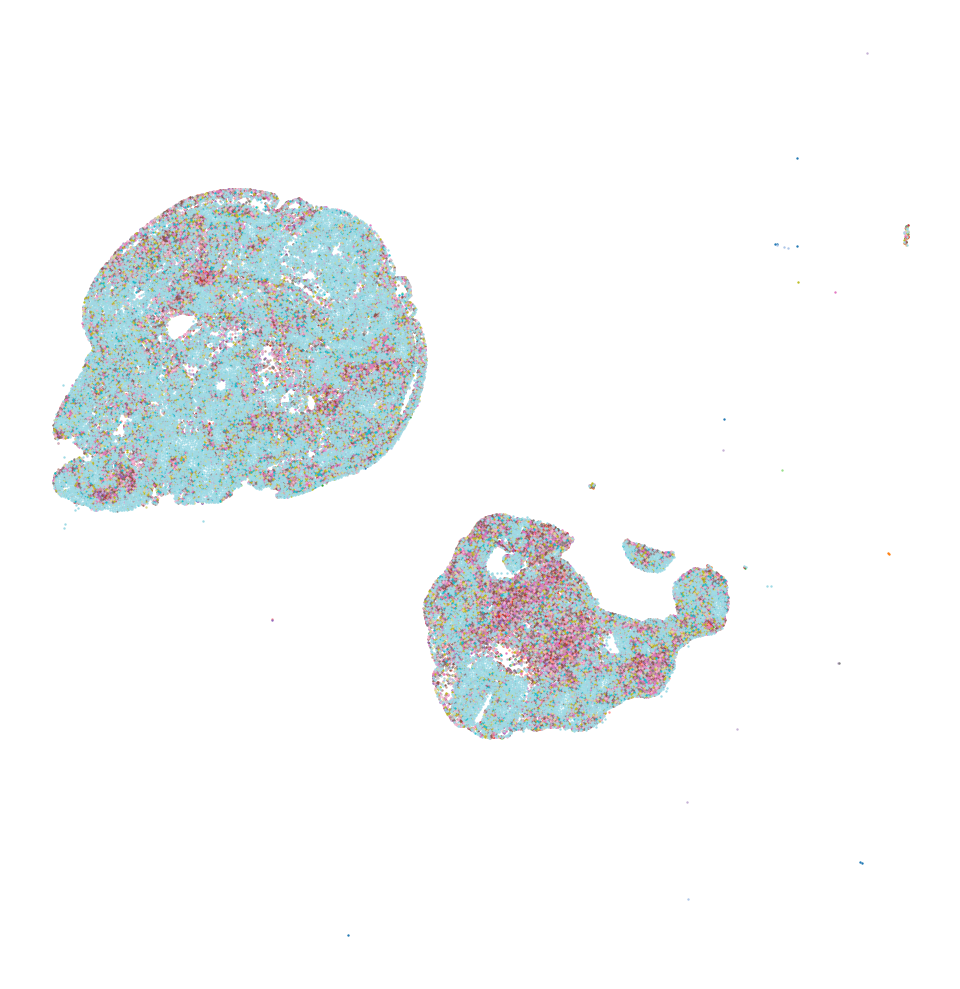

In [4]:
# plotting with matplotlib
labels = ab01.obs['bin_count'].astype(str)
x = ab01.obs['array_col'].values
y = ab01.obs['array_row'].values

unique_labels = sorted(labels.unique(), key=lambda x: int(x))
colors = plt.cm.tab20(range(len(unique_labels)))
label_to_color = dict(zip(unique_labels, colors))

fig, ax = plt.subplots(figsize=(10, 10))
for label in unique_labels:
    mask = labels == label
    ax.scatter(x[mask], y[mask], c=[label_to_color[label]], 
                s=0.5, label=label)

ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.show()

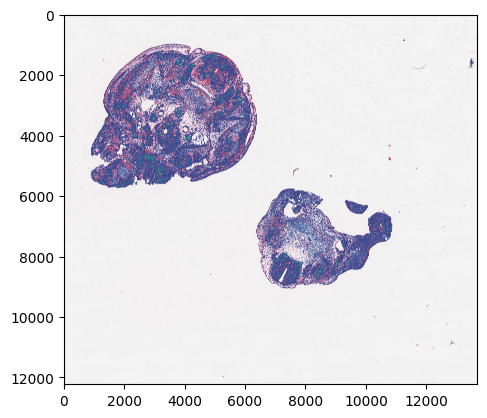

In [5]:
# plotting with bin2cell (no crop)
img, legends = b2c.view_cell_labels(image_path=ab01_img,
                                    labels_npz_path=ab01_seg,
                                    cdata=ab01,
                                    # crop=crop,
                                    fill_key="bin_count",
                                    border_key="labels_joint_source")
plt.imshow(img)

## filtering

In [6]:
# defining cropping boundaries
x = ab01.obs['array_col'].values
y = ab01.obs['array_row'].values

x_min_valid_row = 0   
x_max_valid_row = 2700  

y_min_valid_row = 575 
y_max_valid_row = 2875

valid_mask = ((x >= x_min_valid_row) & 
              (x <= x_max_valid_row) & 
              (y >= y_min_valid_row) & 
              (y <= y_max_valid_row))

ab01_new = ab01[valid_mask].copy()

## after filtering

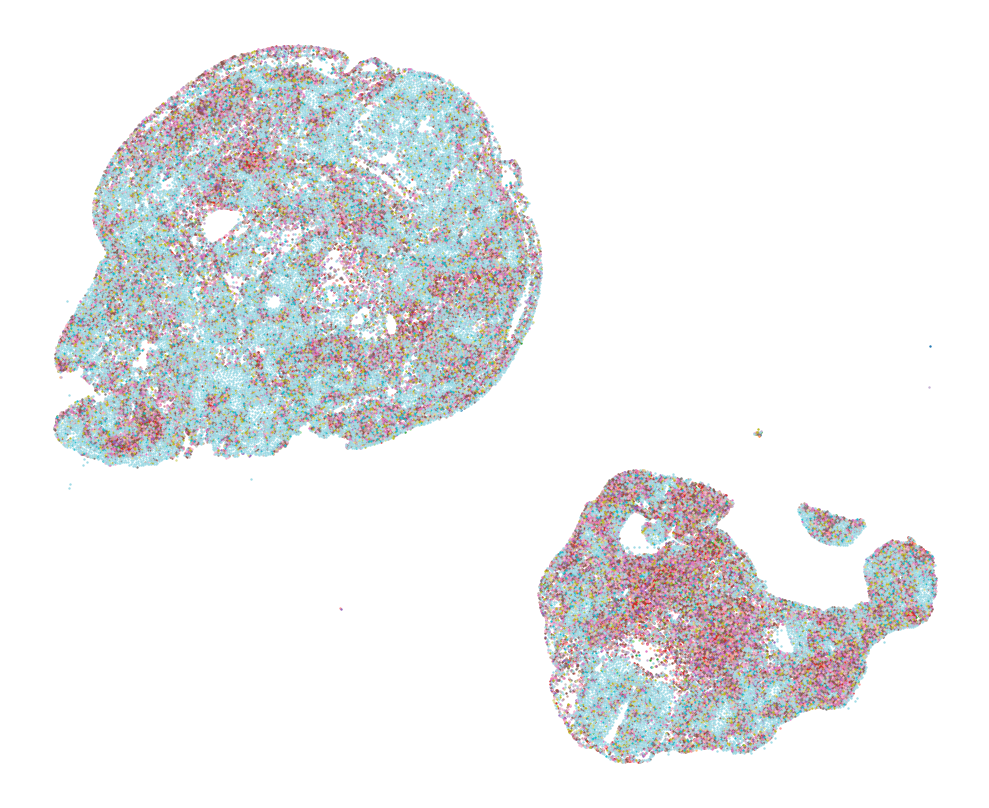

In [7]:
# plotting with matplotlib
labels = ab01_new.obs['bin_count'].astype(str)
x = ab01_new.obs['array_col'].values
y = ab01_new.obs['array_row'].values

unique_labels = sorted(labels.unique(), key=lambda x: int(x))
colors = plt.cm.tab20(range(len(unique_labels)))
label_to_color = dict(zip(unique_labels, colors))

fig, ax = plt.subplots(figsize=(10, 10))
for label in unique_labels:
    mask = labels == label
    ax.scatter(x[mask], y[mask], c=[label_to_color[label]], 
                s=0.5, label=label)

ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.show()

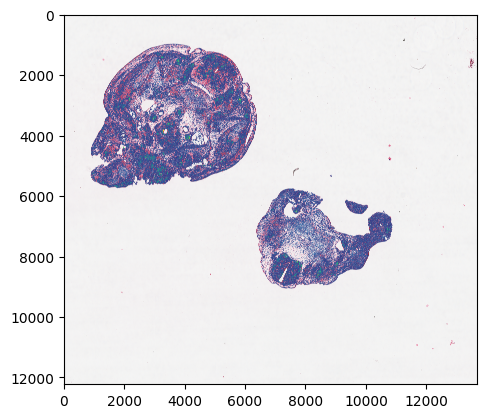

In [8]:
# plotting with bin2cell (no crop)
img, legends = b2c.view_cell_labels(image_path=ab01_img,
                                    labels_npz_path=ab01_seg,
                                    cdata=ab01_new,
                                    # crop=crop,
                                    fill_key="bin_count",
                                    border_key="labels_joint_source")
plt.imshow(img)

In [9]:
ab01_new

AnnData object with n_obs × n_vars = 111497 × 19033
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial', 'spatial_cropped_150_buffer'
    layers: 'raw_counts'

# AB02

## before filtering

In [10]:
ab02

AnnData object with n_obs × n_vars = 68183 × 19031
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial', 'spatial_cropped_150_buffer'
    layers: 'raw_counts'

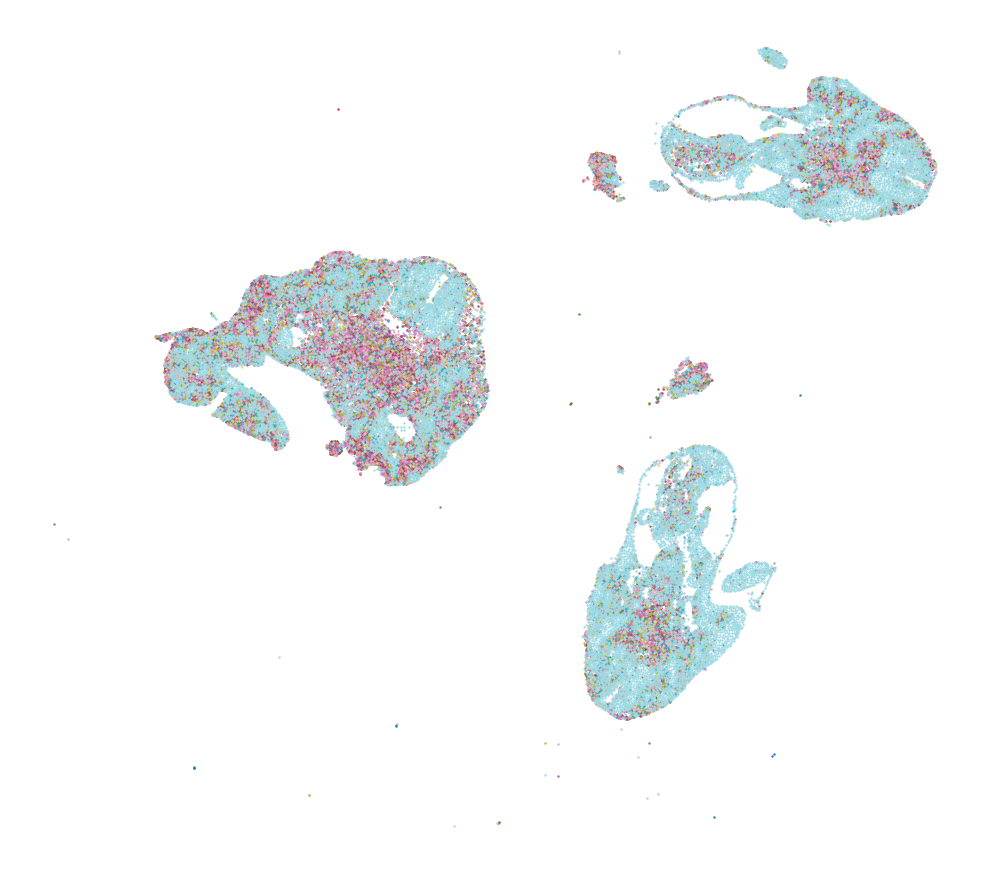

In [11]:
# plotting with matplotlib
labels = ab02.obs['bin_count'].astype(str)
x = ab02.obs['array_col'].values
y = ab02.obs['array_row'].values

unique_labels = sorted(labels.unique(), key=lambda x: int(x))
colors = plt.cm.tab20(range(len(unique_labels)))
label_to_color = dict(zip(unique_labels, colors))

fig, ax = plt.subplots(figsize=(10, 10))
for label in unique_labels:
    mask = labels == label
    ax.scatter(-x[mask], -y[mask], c=[label_to_color[label]], 
                s=0.5, label=label)

ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.show()

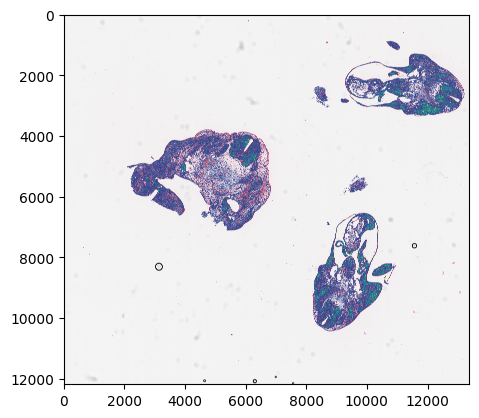

In [12]:
# plotting with bin2cell (no crop)
img, legends = b2c.view_cell_labels(image_path=ab02_img,
                                    labels_npz_path=ab02_seg,
                                    cdata=ab02,
                                    # crop=crop,
                                    fill_key="bin_count",
                                    border_key="labels_joint_source")
plt.imshow(img)

## filtering
use plot_with_grid.py to determine coordinate thresholds

In [13]:
# defining cropping boundaries
x = ab02.obs['array_col'].values
y = ab02.obs['array_row'].values

x_min_valid_row = 0   
x_max_valid_row = 2800  

y_min_valid_row = 600 
y_max_valid_row = 2955

valid_mask = ((x >= x_min_valid_row) & 
              (x <= x_max_valid_row) & 
              (y >= y_min_valid_row) & 
              (y <= y_max_valid_row))

ab02_new = ab02[valid_mask].copy()

## after filtering

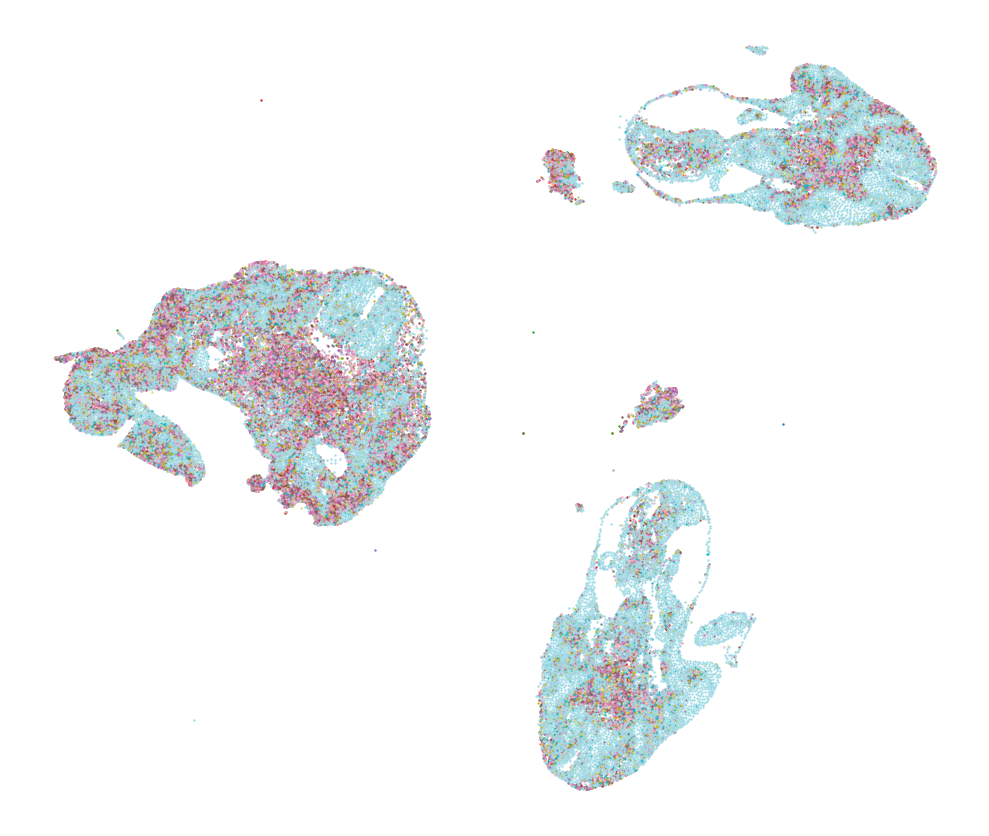

In [14]:
# plotting with matplotlib
labels = ab02_new.obs['bin_count'].astype(str)
x = ab02_new.obs['array_col'].values
y = ab02_new.obs['array_row'].values

unique_labels = sorted(labels.unique(), key=lambda x: int(x))
colors = plt.cm.tab20(range(len(unique_labels)))
label_to_color = dict(zip(unique_labels, colors))

fig, ax = plt.subplots(figsize=(10, 10))
for label in unique_labels:
    mask = labels == label
    ax.scatter(-x[mask], -y[mask], c=[label_to_color[label]], 
                s=0.5, label=label)

ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.show()

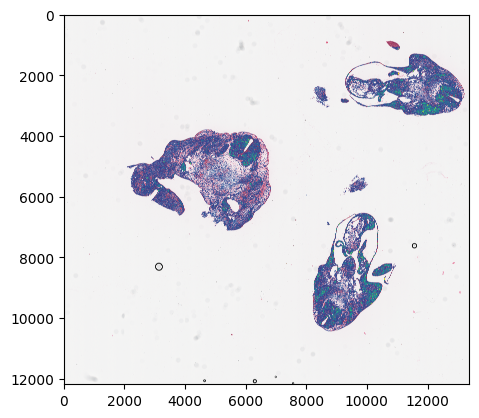

In [15]:
# plotting with bin2cell (no crop)
img, legends = b2c.view_cell_labels(image_path=ab02_img,
                                    labels_npz_path=ab02_seg,
                                    cdata=ab02_new,
                                    # crop=crop,
                                    fill_key="bin_count",
                                    border_key="labels_joint_source")
plt.imshow(img)

In [16]:
ab02_new

AnnData object with n_obs × n_vars = 68008 × 19031
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial', 'spatial_cropped_150_buffer'
    layers: 'raw_counts'

In [17]:
ab01_new.write_h5ad('/Users/rikac/Documents/mansfield_lab/spring_26/AB01_filtered.h5ad', compression='gzip')
ab02_new.write_h5ad('/Users/rikac/Documents/mansfield_lab/spring_26/AB02_filtered.h5ad', compression='gzip')